Shortest path distance found: 3.2973906110354765


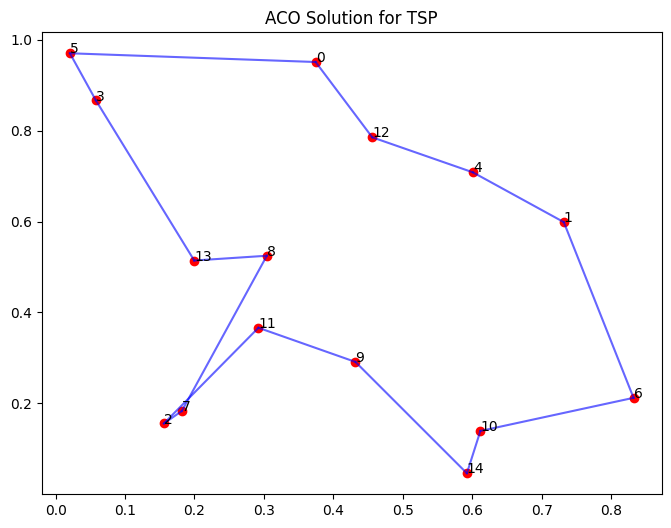

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

class AntColonyOptimization:
    def __init__(self, distances, n_ants, n_best, n_iterations, decay, alpha=1, beta=1):
        """
        Args:
            distances (2D numpy.array): Square matrix of distances. Diagonal is assumed to be np.inf.
            n_ants (int): Number of ants running per iteration
            n_best (int): Number of best ants who deposit pheromone
            n_iterations (int): Number of iterations
            decay (float): Rate it which pheromone decays. The pheromone value is multiplied by decay, so 0.95 is slow decay, 0.5 is fast decay.
            alpha (int or float): Exponent on pheromone, higher alpha gives pheromone more weight. Default=1
            beta (int or float): Exponent on distance, higher beta give distance more weight. Default=1
        """
        self.distances = distances
        self.pheromone = np.ones(self.distances.shape) / len(distances)
        self.all_inds = range(len(distances))
        self.n_ants = n_ants
        self.n_best = n_best
        self.n_iterations = n_iterations
        self.decay = decay
        self.alpha = alpha
        self.beta = beta

    def run(self):
        shortest_path = None
        all_time_shortest_path = ("placeholder", np.inf)
        
        for i in range(self.n_iterations):
            all_paths = self.gen_all_paths()
            self.spread_pheronome(all_paths, self.n_best, shortest_path=shortest_path)
            shortest_path = min(all_paths, key=lambda x: x[1])
            if shortest_path[1] < all_time_shortest_path[1]:
                all_time_shortest_path = shortest_path
            
            self.pheromone = self.pheromone * self.decay

        return all_time_shortest_path

    def spread_pheronome(self, all_paths, n_best, shortest_path):
        sorted_paths = sorted(all_paths, key=lambda x: x[1])
        for path, dist in sorted_paths[:n_best]:
            for move in path:
                self.pheromone[move] += 1.0 / self.distances[move]

    def gen_path_dist(self, path):
        total_dist = 0
        for ele in path:
            total_dist += self.distances[ele]
        return total_dist

    def gen_all_paths(self):
        all_paths = []
        for i in range(self.n_ants):
            path = self.gen_path(0)
            all_paths.append((path, self.gen_path_dist(path)))
        return all_paths

    def gen_path(self, start):
        path = []
        visited = set()
        visited.add(start)
        prev = start
        for i in range(len(self.distances) - 1):
            move = self.pick_move(self.pheromone[prev], self.distances[prev], visited)
            path.append((prev, move))
            prev = move
            visited.add(move)
        path.append((prev, start)) # return to start
        return path

    def pick_move(self, pheromone, dist, visited):
        pheromone = np.copy(pheromone)
        pheromone[list(visited)] = 0

        row = pheromone ** self.alpha * (( 1.0 / dist) ** self.beta)

        norm_row = row / row.sum()
        move = np.random.choice(self.all_inds, 1, p=norm_row)[0]
        return move

# ---  Usage ---

# Generate random cities
np.random.seed(42)
num_cities = 15
cities = np.random.rand(num_cities, 2)

# Calculate distance matrix
distances = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(num_cities):
        if i != j:
            distances[i][j] = np.linalg.norm(cities[i] - cities[j])
        else:
            distances[i][j] = np.inf # Avoid division by zero for self-distance

# Initialize and run ACO
aco = AntColonyOptimization(distances, n_ants=20, n_best=5, n_iterations=100, decay=0.95, alpha=1, beta=2)
shortest_path_edges, shortest_distance = aco.run()

print(f"Shortest path distance found: {shortest_distance}")

# Plotting the result
plt.figure(figsize=(8, 6))
plt.scatter(cities[:, 0], cities[:, 1], c='red', marker='o')

for i, txt in enumerate(range(num_cities)):
    plt.annotate(txt, (cities[i, 0], cities[i, 1]))

for edge in shortest_path_edges:
    start_node, end_node = edge
    plt.plot([cities[start_node, 0], cities[end_node, 0]], 
             [cities[start_node, 1], cities[end_node, 1]], 'b-', alpha=0.6)

plt.title("ACO Solution for TSP")
plt.show()

In [11]:
graph = [[0,8,1,4],[8,0,4,5],[1,4,0,15],[4,5,15,0]]
phermomone = np.ones((4,4))
print("Graph:\n", graph, "\nPheromone:\n", phermomone)

Graph:
 [[0, 8, 1, 4], [8, 0, 4, 5], [1, 4, 0, 15], [4, 5, 15, 0]] 
Pheromone:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


In [ ]:
n_ants = 10
n_best = 5
n_iterations = 100

for ant in range(n_ants):
    visitied = set()
    visitied.add(ant)
    prev = ant
    for step in range(len(graph)-1):
        # Calculate probabilities
        pheromone_row = phermomone[prev]
        distance_row = graph[prev]
        pheromone_row[list(visitied)] = 0  # Avoid visited nodes

        row = pheromone_row ** 1 * ((1.0 / np.array(distance_row)) ** 1)
        norm_row = row / row.sum()
        
        move = np.random.choice(range(len(graph)), 1, p=norm_row)[0]
        visitied.add(move)
        prev = move

C:\Users\vishn\AppData\Local\Temp\ipykernel_18856\3417006939.py:15: RuntimeWarning: divide by zero encountered in divide
  row = pheromone_row ** 1 * ((1.0 / np.array(distance_row)) ** 1)
C:\Users\vishn\AppData\Local\Temp\ipykernel_18856\3417006939.py:15: RuntimeWarning: invalid value encountered in multiply
  row = pheromone_row ** 1 * ((1.0 / np.array(distance_row)) ** 1)


ValueError: probabilities contain NaN